In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

DATA_PATH = Path('data/transformed_cleaned_vw_golf.csv')
df = pd.read_csv(DATA_PATH)
print(f'Loaded {DATA_PATH} with {len(df):,} rows and {df.shape[1]} columns')
df.head()


Loaded data/transformed_cleaned_vw_golf.csv with 6,920 rows and 27 columns


,index,brand,model,registration_date,year,price_in_euro,power_kw,power_ps,fuel_type,fuel_consumption_l_100km,...,T_car_age,color_black,color_blue,color_grey,color_other,color_red,color_silver,color_white,transmission_type_Automatic,transmission_type_Manual
0,213644,volkswagen,Volkswagen Golf,1995-08-01,1995,4970,66,90,Petrol,8.0,...,5.530220,False,True,False,False,False,False,False,False,True
1,213645,volkswagen,Volkswagen Golf,1995-02-01,1995,2590,66,90,Petrol,6.8,...,5.575243,False,True,False,False,False,False,False,True,False
2,213647,volkswagen,Volkswagen Golf,1995-11-01,1995,8900,128,174,Petrol,10.5,...,5.507571,False,True,False,False,False,False,False,True,False
3,213650,volkswagen,Volkswagen Golf,1995-11-01,1995,6399,44,60,Petrol,6.8,...,5.507571,False,True,False,False,False,False,False,False,True
4,213662,volkswagen,Volkswagen Golf,1995-06-01,1995,6600,66,90,Diesel,5.0,...,5.545268,False,False,False,False,True,False,False,False,True


In [2]:
feature_cols = [
    'T_model_age', 'T_car_age', 'T_power_kw', 'T_mileage', 'fuel_consumption_l_100km',
    'transmission_type_Automatic', 'transmission_type_Manual',
    'color_black', 'color_blue', 'color_grey', 'color_other', 'color_red',
    'color_silver', 'color_white'
]

X = df[feature_cols].astype(float)
y = df['price_in_euro'].astype(float)

print('Feature matrix shape:', X.shape)
print('Target summary:')
print(y.describe())


Feature matrix shape: (6920, 14)
Target summary:
count     6920.000000
mean     13595.728179
std       9254.426381
min        399.000000
25%       6750.000000
50%      12290.000000
75%      17990.000000
max      97050.000000
Name: price_in_euro, dtype: float64


In [3]:
corr = df[feature_cols + ['price_in_euro']].corr(numeric_only=True)
price_corr = corr['price_in_euro'].sort_values(ascending=False)
price_corr


price_in_euro                  1.000000
T_power_kw                     0.674538
transmission_type_Automatic    0.466808
color_red                      0.198084
color_white                    0.116456
color_other                    0.047075
color_grey                     0.031106
color_blue                    -0.060817
color_black                   -0.072843
color_silver                  -0.135825
fuel_consumption_l_100km      -0.208933
transmission_type_Manual      -0.466808
T_mileage                     -0.749034
T_car_age                     -0.841948
T_model_age                   -0.843118
Name: price_in_euro, dtype: float64

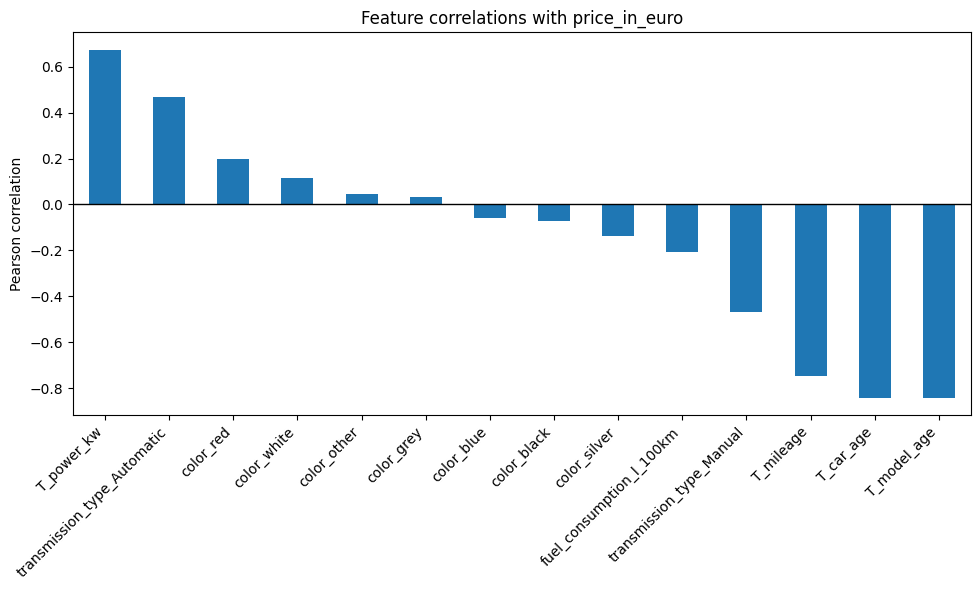

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
price_corr.drop('price_in_euro').plot(kind='bar', ax=ax)
ax.set_title('Feature correlations with price_in_euro')
ax.set_ylabel('Pearson correlation')
ax.axhline(0.0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

def eval_reg(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} RMSE={rmse:.2f} | R²={r2:.3f}")

print('Linear Regression quick baseline')
eval_reg(y_train, lr.predict(X_train), 'Train')
eval_reg(y_val, lr.predict(X_val), 'Validation')
eval_reg(y_test, lr.predict(X_test), 'Test')


Linear Regression quick baseline
Train RMSE=3613.14 | R²=0.852
Validation RMSE=4181.70 | R²=0.797
Test RMSE=3230.78 | R²=0.864


In [6]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)
coef_df


,feature,coefficient
2,T_power_kw,7568.354248
0,T_model_age,-3606.911810
1,T_car_age,1928.331737
5,transmission_type_Automatic,928.048375
6,transmission_type_Manual,-928.048375
4,fuel_consumption_l_100km,654.782619
9,color_grey,-412.856944
10,color_other,365.624223
8,color_blue,250.294282
12,color_silver,-225.742900


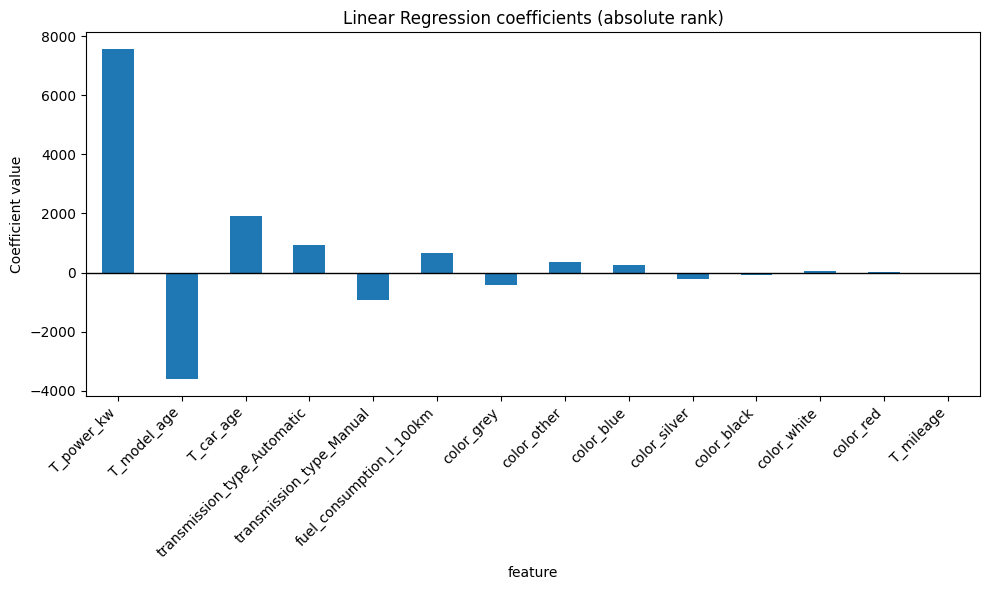

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
coef_df.set_index('feature')['coefficient'].plot(kind='bar', ax=ax)
ax.set_title('Linear Regression coefficients (absolute rank)')
ax.set_ylabel('Coefficient value')
ax.axhline(0.0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
